# 相对位置编码与旋转位置编码（RoPE）

本 Notebook 从零实现两种现代 Transformer 位置编码方案：
- **相对位置编码（Relative Position Encoding）**：通过可学习的相对位置嵌入参数，直接在注意力分数中注入 token 间的相对距离信息。
- **旋转位置编码（RoPE，Rotary Position Embedding）**：通过复数旋转矩阵将绝对位置信息转换为相对位置依赖，是 LLaMA / GPT-NeoX / DeepSeek 等主流大模型的标准位置编码方案。

## 一、相对位置编码（Relative Position Encoding）

**核心思想**：在注意力分数计算时，不仅考虑 token 内容的相似度，还引入两个 token 之间的相对距离（偏移量）对应的可学习嵌入向量，使注意力感知位置关系。

In [1]:
import torch                              # 导入 PyTorch 深度学习框架
import torch.nn as nn                    # 导入神经网络模块（Linear、Parameter、Module 等）
import math                              # 导入标准数学库（sqrt 等）
from torch.nn import functional as F    # 导入函数式 API（softmax、embedding 等无状态函数）


class RelativePositionEmbedding(nn.Module):
    """
    可学习的相对位置编码模块（Trainable Relative Position Embedding）。

    核心思想：
        对于序列中位置 i 和位置 j 的 token，其相对距离为 (j - i)，
        范围为 [-(max_seq_len-1), max_seq_len-1]，共 2*max_seq_len-1 种。
        为每种相对距离学习一个 embedding_dim 维的密集向量，
        在注意力计算时将该向量融入到注意力分数中。

    与绝对位置编码的区别：
        绝对位置编码给每个位置 i 一个固定向量，不包含位置间关系信息。
        相对位置编码直接对"距离"建模，使注意力分数感知 token 间距。

    参数:
        max_seq_len   (int): 支持的最大序列长度，决定相对位置的范围
        embedding_dim (int): 每个相对位置对应的嵌入向量维度
    """
    def __init__(self, max_seq_len: int, embedding_dim: int):
        super().__init__()                        # 调用 nn.Module 父类初始化
        self.max_seq_len = max_seq_len            # 最大序列长度（int），决定相对位置矩阵行数
        self.embedding_dim = embedding_dim        # 嵌入向量维度（int）

        # 相对位置嵌入参数矩阵，形状: (max_seq_len * 2 - 1, embedding_dim)
        # max_seq_len * 2 - 1 : 相对距离的总种类数
        #   例如 max_seq_len=10 时，相对距离范围 [-9, 9]，共 19 种
        # nn.Parameter : 将张量注册为可训练参数（requires_grad=True）
        # torch.randn  : 用标准正态分布初始化
        self.relative_positions = nn.Parameter(
            torch.randn(max_seq_len * 2 - 1, embedding_dim)
        )

    def forward(self, seq_len: int):
        """
        根据序列长度生成相对位置嵌入张量。

        参数:
            seq_len (int): 当前序列的实际长度（≤ max_seq_len）

        返回:
            torch.Tensor: 相对位置嵌入，形状 (seq_len, seq_len, embedding_dim)
                          [i, j, :] 表示位置 i 相对于位置 j 的嵌入向量
        """
        # 生成相对位置索引矩阵，形状: (seq_len, seq_len)，值为非负整数
        relative_positions_matrix = self._generate_relative_positions_matrix(seq_len)

        # F.embedding 根据整数索引从参数矩阵中查表：
        #   输入 relative_positions_matrix 形状: (seq_len, seq_len)
        #   参数 self.relative_positions    形状: (2*max_seq_len-1, embedding_dim)
        #   输出 relative_embeddings        形状: (seq_len, seq_len, embedding_dim)
        relative_embeddings = F.embedding(relative_positions_matrix, self.relative_positions)
        return relative_embeddings  # 返回: torch.Tensor，形状 (seq_len, seq_len, embedding_dim)

    def _generate_relative_positions_matrix(self, seq_len: int):
        """
        生成相对位置索引矩阵（偏移后的非负整数矩阵）。

        参数:
            seq_len (int): 当前序列长度

        返回:
            torch.Tensor: 形状 (seq_len, seq_len) 的非负整数矩阵
                          matrix[i, j] = (j - i) + (max_seq_len - 1)
                          偏移后的值范围: [0, 2*max_seq_len-2]，恰好是相对位置嵌入的行索引
        """
        # torch.arange(seq_len) : 生成 [0, 1, ..., seq_len-1] 的 1D 张量
        range_vec = torch.arange(seq_len)  # 类型: torch.Tensor，形状: (seq_len,)

        # range_vec.unsqueeze(0) 形状: (1, seq_len)
        # .expand(seq_len, seq_len) : 沿第 0 维复制，形状变为 (seq_len, seq_len)
        # range_matrix[i, j] = j（第 i 行全为 [0, 1, ..., seq_len-1]）
        range_matrix = range_vec.unsqueeze(0).expand(seq_len, seq_len)

        # range_matrix - range_matrix.t() : 矩阵减其转置
        # distance_matrix[i, j] = j - i（取值范围: [-(seq_len-1), seq_len-1]，含负数）
        distance_matrix = range_matrix - range_matrix.t()

        # 将距离值偏移 (max_seq_len - 1)，使最小值从负数变为 0（非负化，可作为查表索引）
        # distance_matrix[i, j] = (j - i) + (max_seq_len - 1)
        # 取值范围: [0, 2*max_seq_len-2]
        distance_matrix = distance_matrix + self.max_seq_len - 1

        return distance_matrix  # 类型: torch.Tensor，形状: (seq_len, seq_len)，值: 非负整数


class MultiHeadAttention(nn.Module):
    """
    融合相对位置编码的多头注意力机制。

    在标准多头注意力的基础上，在注意力分数中加入了相对位置感知项：
        attention_scores[i, j] = query[i] · key[j] + query[i] · rel_emb[i, j]

    其中 rel_emb[i, j] 为位置 i 相对于位置 j 的可学习嵌入向量，
    通过 einsum 高效计算相对位置注意力贡献。

    参数:
        embed_dim   (int): 模型总嵌入维度，等于 num_heads × head_dim
        num_heads   (int): 注意力头数
        max_seq_len (int): 最大序列长度，传递给 RelativePositionEmbedding
    """
    def __init__(self, embed_dim: int, num_heads: int, max_seq_len: int):
        super().__init__()
        self.embed_dim = embed_dim              # 总嵌入维度（int）
        self.num_heads = num_heads              # 注意力头数（int）
        self.head_dim = embed_dim // num_heads  # 每个头的维度（int），= embed_dim / num_heads

        # Q/K/V 线性投影层，将输入从 embed_dim 映射到 embed_dim
        self.q_proj = nn.Linear(embed_dim, embed_dim)  # Query 投影，输入维: embed_dim
        self.k_proj = nn.Linear(embed_dim, embed_dim)  # Key   投影，输入维: embed_dim
        self.v_proj = nn.Linear(embed_dim, embed_dim)  # Value 投影，输入维: embed_dim

        # 相对位置编码模块，嵌入维度等于每个头的维度（head_dim）
        # 因为相对位置信息需要与每个头的 Q 向量做内积
        self.rel_pos_embeddings = RelativePositionEmbedding(max_seq_len, self.head_dim)

        # 输出线性投影层，将多头拼接结果映射回 embed_dim
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, query: torch.Tensor, key: torch.Tensor, value: torch.Tensor):
        """
        多头注意力前向传播（含相对位置编码）。

        参数:
            query (torch.Tensor): 查询张量，形状 (batch_size, seq_len, embed_dim)
            key   (torch.Tensor): 键张量，  形状 (batch_size, seq_len, embed_dim)
            value (torch.Tensor): 值张量，  形状 (batch_size, seq_len, embed_dim)

        返回:
            output (torch.Tensor): 输出张量，形状 (batch_size, seq_len, embed_dim)
        """
        batch_size, seq_len, embed_dim = query.size()  # 解包输入形状，各为 int

        # ── Q/K/V 线性投影 + 重塑为多头形式 ────────────────────────────────────
        # .view(batch_size, seq_len, num_heads, head_dim) : 将 embed_dim 拆分为 num_heads 个 head_dim
        # .transpose(1, 2) : 交换 seq_len 和 num_heads 维度
        # 结果形状: (batch_size, num_heads, seq_len, head_dim)
        query = self.q_proj(query).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        key   = self.k_proj(key).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        value = self.v_proj(value).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # ── 标准内容注意力分数 ──────────────────────────────────────────────────
        # query 形状: (batch_size, num_heads, seq_len, head_dim)
        # key.transpose(-1, -2) 形状: (batch_size, num_heads, head_dim, seq_len)
        # 矩阵乘后形状: (batch_size, num_heads, seq_len, seq_len)
        attention_scores = torch.matmul(query, key.transpose(-1, -2))

        # ── 相对位置注意力分数 ──────────────────────────────────────────────────
        # 调用 RelativePositionEmbedding.forward(seq_len)
        # rel_pos_embeddings 形状: (seq_len, seq_len, head_dim)
        rel_pos_embeddings = self.rel_pos_embeddings(seq_len)

        # einsum 'bhld,lrd->bhlr':
        #   b = batch_size, h = num_heads, l = seq_len（query 的位置）
        #   r = seq_len（key 的位置），d = head_dim
        #   对每个 (batch, head, query_pos, key_pos)，计算 query[b,h,l,:] · rel_emb[l,r,:]
        # 结果形状: (batch_size, num_heads, seq_len, seq_len)
        rel_attention_scores = torch.einsum('bhld,lrd->bhlr', query, rel_pos_embeddings)

        # 将相对位置注意力分数加到内容注意力分数上（两者形状相同）
        attention_scores += rel_attention_scores

        # ── 缩放与 Softmax ──────────────────────────────────────────────────────
        # 缩放因子 sqrt(head_dim)：防止点积值过大导致 softmax 梯度消失
        attention_scores = attention_scores / math.sqrt(self.head_dim)

        # 对最后一维（key 序列维度）做 Softmax，得到注意力权重（概率分布）
        # attention_weights 形状: (batch_size, num_heads, seq_len, seq_len)，行和为 1
        attention_weights = F.softmax(attention_scores, dim=-1)

        # ── 加权求和值向量 ──────────────────────────────────────────────────────
        # 注意力权重 × value：输出形状 (batch_size, num_heads, seq_len, head_dim)
        output = torch.matmul(attention_weights, value)

        # ── 重塑并输出投影 ──────────────────────────────────────────────────────
        # .transpose(1, 2) : 交换回 (batch_size, seq_len, num_heads, head_dim)
        # .contiguous()    : 确保内存连续（transpose 后视图不连续，view 需要连续内存）
        # .view(batch_size, seq_len, embed_dim) : 将多头结果拼接为 embed_dim
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)

        output = self.out_proj(output)  # 输出线性投影，形状: (batch_size, seq_len, embed_dim)
        return output  # 返回: torch.Tensor，形状 (batch_size, seq_len, embed_dim)


# ── 示例运行与测试 ──────────────────────────────────────────────────────────────
max_seq_len = 10  # 最大序列长度（int），相对位置嵌入矩阵行数为 2*10-1=19
embed_dim   = 64  # 总嵌入维度（int）
num_heads   = 4   # 注意力头数（int），每头维度 = 64 // 4 = 16
batch_size  = 2   # 批次大小（int）
seq_len     = 5   # 实际序列长度（int），小于 max_seq_len

# 创建随机 Q/K/V 张量，类型: torch.Tensor，形状: (batch_size, seq_len, embed_dim)
query = torch.randn(batch_size, seq_len, embed_dim)
key   = torch.randn(batch_size, seq_len, embed_dim)
value = torch.randn(batch_size, seq_len, embed_dim)

# 实例化融合相对位置编码的多头注意力模块
attention = MultiHeadAttention(embed_dim, num_heads, max_seq_len)

# 打印相对位置矩阵（5×5），验证索引计算是否正确
# 对角线应为 max_seq_len-1=9（相对距离=0），上三角>9，下三角<9
print("相对位置矩阵:")
print(attention.rel_pos_embeddings._generate_relative_positions_matrix(5))

# 验证相对位置嵌入参数矩阵形状：应为 (2*10-1, 16) = (19, 16)
print(f"相对位置嵌入参数形状: {attention.rel_pos_embeddings.relative_positions.shape}")

# 验证 seq_len=5 时的相对位置嵌入输出形状：应为 (5, 5, 16)
print(f"序列长度为5的相对位置嵌入形状: {attention.rel_pos_embeddings(5).shape}")

# 执行完整的多头注意力前向传播
output = attention(query, key, value)
# output 形状应为 (batch_size=2, seq_len=5, embed_dim=64)
print(f"输出形状: {output.shape}")

相对位置矩阵:
tensor([[ 9, 10, 11, 12, 13],
        [ 8,  9, 10, 11, 12],
        [ 7,  8,  9, 10, 11],
        [ 6,  7,  8,  9, 10],
        [ 5,  6,  7,  8,  9]])
相对位置嵌入参数形状: torch.Size([19, 16])
序列长度为5的相对位置嵌入形状: torch.Size([5, 5, 16])
输出形状: torch.Size([2, 5, 64])


## 二、旋转位置编码（RoPE，Rotary Position Embedding）

**核心思想**：将 token 的绝对位置信息以旋转矩阵的形式注入到 Q 和 K 向量中。
- 对于位置 m 处的向量 $\mathbf{q}$，乘以旋转矩阵 $R_m$：$\tilde{\mathbf{q}}_m = R_m \mathbf{q}$
- 注意力点积 $\tilde{\mathbf{q}}_m \cdot \tilde{\mathbf{k}}_n = \mathbf{q}^T R_{n-m} \mathbf{k}$，天然包含相对距离 $(n-m)$
- 频率 $\theta_d = 10000^{-2d/\text{dim}}$，不同维度对使用不同旋转频率，低维高频、高维低频

**优势**：无需额外参数、训练时序列长度外推能力强（结合 YaRN/ABF 等扩展技术）、被 LLaMA/GLM-4/DeepSeek 等主流模型采用。

测试旋转位置编码(RoPE)
输入形状: torch.Size([2, 10, 128])
输出形状: torch.Size([2, 10, 128])
注意力权重形状: torch.Size([2, 8, 10, 10])

测试相对位置特性:
序列1注意力权重形状: torch.Size([1, 8, 5, 5])
序列2注意力权重形状: torch.Size([1, 8, 7, 7])
RoPE有助于保持序列中元素的相对位置关系

比较RoPE与绝对位置编码:
RoPE优势:
1. 更好的相对位置建模（点积天然包含相对位置差）
2. 对序列长度的泛化能力更强（结合 YaRN/ABF 可外推）
3. 在长序列上性能更稳定（被 LLaMA/GLM-4/DeepSeek 采用）

绝对位置编码特点:
1. 直接以加法形式添加到输入 embedding（简单高效）
2. 可能丢失相对位置信息（Q·K 点积中位置信息被稀释）
3. 对训练时未见过的序列长度泛化性较差


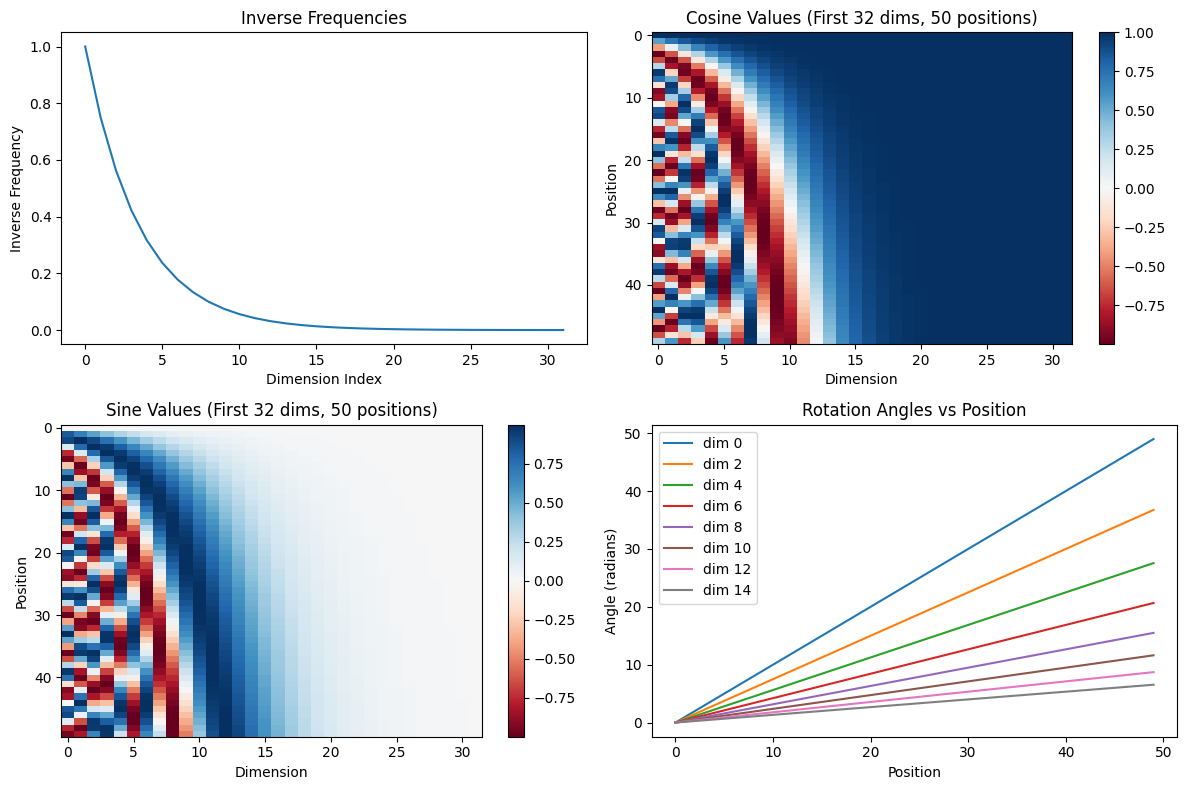


旋转位置编码(RoPE)示例完成！


In [2]:
import torch                              # PyTorch 深度学习框架
import torch.nn as nn                    # 神经网络模块
import math                              # 数学库（log 等）
import matplotlib.pyplot as plt          # 绘图库，用于可视化 RoPE 频率特性
import numpy as np                       # 数值计算库（供 matplotlib 使用）


class RotaryPositionalEmbedding(nn.Module):
    """
    旋转位置编码（RoPE，Rotary Position Embedding）。

    核心思想：
        对于位置 m 处的 d 维向量 q，将其每两个相邻维度视为一个复数对 (q_{2i}, q_{2i+1})，
        并乘以旋转角度 θ_{m,i} = m × θ_i，其中 θ_i = base^(-2i/dim)（逆频率）。
        旋转后的 Q 和 K 做点积，天然包含两者的相对位置差 (n-m)，无需额外运算。

    与绝对位置编码（Sinusoidal）的关系：
        两者都使用三角函数，但 RoPE 将位置信息编码在旋转操作中（乘法），
        绝对位置编码将位置信息编码为加法偏移。

    参数:
        dim                      (int): 每个注意力头的特征维度（head_dim）
        max_position_embeddings  (int): 最大序列长度，预计算此长度范围内的 cos/sin 缓存，默认 2048
        base                     (int): 旋转频率的基底，默认 10000（与 Transformer 原论文一致）
    """

    def __init__(self, dim, max_position_embeddings=2048, base=10000):
        super().__init__()
        self.dim = dim                                          # 每头特征维度（int）
        self.max_position_embeddings = max_position_embeddings  # 最大序列长度（int）
        self.base = base                                        # 频率基底（int/float）

        # 计算各维度对的逆频率（inverse frequency）：θ_i = base^(-2i/dim)
        # torch.arange(0, dim, 2) : 生成 [0, 2, 4, ..., dim-2]，共 dim//2 个偶数索引
        # inv_freq 类型: torch.Tensor，形状: (dim//2,)，值范围: (0, 1]
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))

        # register_buffer : 将张量注册为模块的持久化缓冲区
        # 缓冲区会随模型一起保存和加载，且随模型 .to(device) 自动迁移设备，但不参与梯度计算
        self.register_buffer('inv_freq', inv_freq)

        # 预计算 cos/sin 缓存，避免每次前向传播重复计算
        self._set_cos_sin_cache(max_position_embeddings)

    def _set_cos_sin_cache(self, seq_len):
        """
        预计算并缓存所有位置的 cos 和 sin 旋转值。

        参数:
            seq_len (int): 需要预计算的序列长度（位置数量）

        返回:
            None（结果存储在缓冲区 cos_cached 和 sin_cached 中）
        """
        # 位置索引向量 [0, 1, ..., seq_len-1]，数据类型与 inv_freq 一致
        # t 类型: torch.Tensor，形状: (seq_len,)
        t = torch.arange(seq_len, dtype=self.inv_freq.dtype, device=self.inv_freq.device)

        # ── torch.outer 接口说明 ──────────────────────────────────────────────
        # 接口: torch.outer(input, vec2, *, out=None) -> Tensor
        # 功能: 计算两个一维张量的「外积」（outer product），
        #       即第一个向量的每个元素与第二个向量的全部元素逐一相乘，
        #       结果构成一个二维矩阵。
        #
        # 参数:
        #   input (Tensor): 第一个一维向量，形状 (n,)
        #                   此处为位置索引向量 t，t[m] = m（m 为 token 在序列中的位置）
        #                   形状: (seq_len,)，dtype 与 inv_freq 保持一致
        #   vec2  (Tensor): 第二个一维向量，形状 (m,)
        #                   此处为频率倒数向量 self.inv_freq，
        #                   inv_freq[i] = 1 / (10000^(2i/dim))，即第 i 个维度对应的旋转基频
        #                   形状: (dim//2,)，其中 dim 为注意力头的维度
        #
        # 返回值:
        #   Tensor，形状: (n, m) = (seq_len, dim//2)
        #   result[m_idx, i] = t[m_idx] * inv_freq[i]
        #                    = m_idx * (1 / 10000^(2i/dim))
        #                    = 位置 m_idx 在第 i 个旋转维度上的旋转角度 θ_{m,i}
        #
        # 等价写法（无需手动广播）:
        #   freqs = t.unsqueeze(1) * self.inv_freq.unsqueeze(0)
        #   # t.unsqueeze(1)          形状: (seq_len, 1)
        #   # inv_freq.unsqueeze(0)   形状: (1, dim//2)
        #   # 广播相乘后             形状: (seq_len, dim//2)
        #
        # 与 torch.ger 的关系:
        #   torch.outer 是 torch.ger 的别名，功能完全相同，推荐使用 outer（语义更清晰）
        #
        # 此处的物理意义:
        #   RoPE（旋转位置编码）要求每个 token 在每个维度对上旋转角度为
        #       θ_{m,i} = m × θ_i = m / 10000^(2i/dim)
        #   外积恰好一次性生成所有 (位置, 维度) 组合的角度矩阵，
        #   避免了双重 for 循环，计算高效。
        # ────────────────────────────────────────────────────────────────────────
        # freqs 类型: torch.Tensor，形状: (seq_len, dim//2)
        # freqs[m, i] = m * inv_freq[i]，即位置 m 在第 i 维的旋转角度
        freqs = torch.outer(t, self.inv_freq)

        # 将 freqs 在最后一维拼接两份，使维度从 dim//2 扩展到 dim
        # 拼接后 emb[m, :dim//2] = emb[m, dim//2:] = freqs[m]
        # 这样可以对每对 (q_{2i}, q_{2i+1}) 独立应用相同的旋转角度
        # emb 类型: torch.Tensor，形状: (seq_len, dim)
        emb = torch.cat((freqs, freqs), dim=-1)

        # 缓存 cos 和 sin 值，形状均为 (seq_len, dim)
        self.register_buffer('cos_cached', emb.cos())  # cos_cached[m, i] = cos(θ_{m,i})
        self.register_buffer('sin_cached', emb.sin())  # sin_cached[m, i] = sin(θ_{m,i})

    def forward(self, x, seq_len=None):
        """
        将旋转位置编码应用到输入张量 x。

        参数:
            x        (torch.Tensor): 形状 (batch_size, seq_len, num_heads, head_dim)
            seq_len  (int, 可选):    序列长度；若为 None 则从 x.shape[1] 自动推断

        返回:
            torch.Tensor: 应用 RoPE 后的张量，形状与 x 相同
        """
        if seq_len is None:
            seq_len = x.shape[1]  # 从输入张量的第 1 维（序列维）自动推断序列长度

        # 若当前序列长度超过预计算缓存，则重新计算更长的缓存
        if seq_len > self.cos_cached.shape[0]:
            self._set_cos_sin_cache(seq_len)

        # 截取需要的长度（前 seq_len 个位置的 cos/sin 值）
        # cos, sin 形状: (seq_len, dim)
        cos = self.cos_cached[:seq_len]
        sin = self.sin_cached[:seq_len]

        return self.apply_rotary_pos_emb(x, cos, sin)  # 返回旋转后的张量

    def apply_rotary_pos_emb(self, x, cos, sin):
        """
        执行旋转位置编码的核心运算（复数乘法的实数分解）。

        旋转公式（对每对相邻维度 (a=x_{2i}, b=x_{2i+1})）：
            a' = a * cos(θ) - b * sin(θ)
            b' = a * sin(θ) + b * cos(θ)
        等价于复数乘法：(a + bi) × e^{iθ} = (a + bi)(cosθ + i·sinθ)

        参数:
            x   (torch.Tensor): 形状 (batch_size, seq_len, num_heads, head_dim)
            cos (torch.Tensor): 形状 (seq_len, head_dim)
            sin (torch.Tensor): 形状 (seq_len, head_dim)

        返回:
            torch.Tensor: 旋转后的张量，形状与 x 相同
        """
        # 扩展 cos/sin 的维度以支持广播
        # (seq_len, head_dim) → (1, seq_len, 1, head_dim)，可以广播到 (bs, seq_len, heads, dim)
        cos = cos.unsqueeze(0).unsqueeze(2)  # 形状: (1, seq_len, 1, head_dim)
        sin = sin.unsqueeze(0).unsqueeze(2)  # 形状: (1, seq_len, 1, head_dim)

        # 按偶数/奇数索引分离 x 的维度，分别对应复数实部和虚部
        # x1 形状: (bs, seq_len, heads, head_dim//2)，取偶数索引维度（复数实部 a）
        # x2 形状: (bs, seq_len, heads, head_dim//2)，取奇数索引维度（复数虚部 b）
        x1, x2 = x[..., ::2], x[..., 1::2]

        # 复数旋转的实数实现：
        # 新实部 a' = a*cos - b*sin（从 cos/sin 中取偶数索引对应的值）
        rotated_x1 = x1 * cos[..., ::2] - x2 * sin[..., ::2]
        # 新虚部 b' = a*sin + b*cos（取奇数索引对应的值）
        rotated_x2 = x1 * sin[..., 1::2] + x2 * cos[..., 1::2]

        # 将旋转后的实部和虚部交错写回原来的偶/奇位置
        rotated_x = torch.zeros_like(x)        # 创建与 x 形状和类型相同的全零张量
        rotated_x[..., ::2] = rotated_x1       # 写回偶数维度（旋转后实部）
        rotated_x[..., 1::2] = rotated_x2      # 写回奇数维度（旋转后虚部）

        return rotated_x  # 返回: torch.Tensor，形状与输入 x 相同


class MultiHeadAttentionWithRoPE(nn.Module):
    """
    集成 RoPE 的多头注意力机制。

    与标准多头注意力的区别：在计算注意力分数前，先对 Q 和 K 分别应用 RoPE 旋转，
    从而使点积自然包含相对位置信息，而无需额外的位置相关参数。
    V 不施加旋转（旋转的目的是让注意力分数感知相对位置，与 V 无关）。

    参数:
        d_model                 (int): 模型总嵌入维度
        num_heads               (int): 注意力头数
        max_position_embeddings (int): 最大序列长度，传递给 RotaryPositionalEmbedding，默认 2048
    """

    def __init__(self, d_model, num_heads, max_position_embeddings=2048):
        super().__init__()
        self.d_model = d_model          # 总嵌入维度（int）
        self.num_heads = num_heads      # 注意力头数（int）
        self.head_dim = d_model // num_heads  # 每头维度（int），= d_model / num_heads

        # 验证 d_model 可被 num_heads 整除
        assert self.head_dim * num_heads == d_model, "d_model 必须能被 num_heads 整除"

        # Q/K/V/O 线性投影层（与标准 MHA 相同）
        self.q_proj = nn.Linear(d_model, d_model)  # Query 投影
        self.k_proj = nn.Linear(d_model, d_model)  # Key   投影
        self.v_proj = nn.Linear(d_model, d_model)  # Value 投影
        self.o_proj = nn.Linear(d_model, d_model)  # 输出  投影（原论文记为 W_O）

        # RoPE 模块，针对每个头的维度（head_dim）计算旋转编码
        self.rotary_emb = RotaryPositionalEmbedding(self.head_dim, max_position_embeddings)

        # 注意力缩放因子：1 / sqrt(head_dim)，防止点积值过大
        # head_dim ** -0.5 等价于 1 / sqrt(head_dim)，类型: float
        self.scale = self.head_dim ** -0.5

    def forward(self, x, mask=None):
        """
        前向传播：含 RoPE 的多头注意力计算。

        参数:
            x    (torch.Tensor):        输入张量，形状 (batch_size, seq_len, d_model)
            mask (torch.Tensor, 可选):  注意力掩码，形状 (batch_size, num_heads, seq_len, seq_len)
                                        值为 0 的位置将被屏蔽（填充为极小值 -1e9）

        返回:
            output      (torch.Tensor): 形状 (batch_size, seq_len, d_model)
            attn_weights(torch.Tensor): 形状 (batch_size, num_heads, seq_len, seq_len)
        """
        batch_size, seq_len, _ = x.shape  # 解包批次大小和序列长度（_=d_model，不直接使用）

        # ── 线性投影 ──────────────────────────────────────────────────────────
        q = self.q_proj(x)  # 形状: (batch_size, seq_len, d_model)
        k = self.k_proj(x)  # 形状: (batch_size, seq_len, d_model)
        v = self.v_proj(x)  # 形状: (batch_size, seq_len, d_model)

        # ── 重塑为多头形式 ────────────────────────────────────────────────────
        # 将 d_model 拆分为 (num_heads, head_dim)，形状变为 (bs, seq_len, num_heads, head_dim)
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_dim)

        # ── 应用 RoPE（只对 Q 和 K，不对 V）──────────────────────────────────
        # RoPE 旋转后 Q 和 K 的点积天然包含相对位置信息
        q = self.rotary_emb(q, seq_len)  # 返回形状: (bs, seq_len, num_heads, head_dim)
        k = self.rotary_emb(k, seq_len)  # 返回形状: (bs, seq_len, num_heads, head_dim)

        # ── 转置为注意力计算所需格式 ──────────────────────────────────────────
        # (bs, seq_len, num_heads, head_dim) → (bs, num_heads, seq_len, head_dim)
        q = q.transpose(1, 2)  # 形状: (batch_size, num_heads, seq_len, head_dim)
        k = k.transpose(1, 2)  # 形状: (batch_size, num_heads, seq_len, head_dim)
        v = v.transpose(1, 2)  # 形状: (batch_size, num_heads, seq_len, head_dim)

        # ── 计算缩放点积注意力分数 ────────────────────────────────────────────
        # k.transpose(-2, -1) 形状: (bs, num_heads, head_dim, seq_len)
        # 结果形状: (batch_size, num_heads, seq_len, seq_len)
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale

        # ── 可选：应用注意力掩码 ──────────────────────────────────────────────
        # masked_fill 将 mask==0 的位置填充为极小值，经 softmax 后趋近于 0
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # ── Softmax 归一化 ────────────────────────────────────────────────────
        # attn_weights 形状: (batch_size, num_heads, seq_len, seq_len)，每行为概率分布
        attn_weights = torch.softmax(scores, dim=-1)

        # ── 加权聚合 Value ────────────────────────────────────────────────────
        # attn_output 形状: (batch_size, num_heads, seq_len, head_dim)
        attn_output = torch.matmul(attn_weights, v)

        # ── 重组多头并输出投影 ────────────────────────────────────────────────
        # .transpose(1,2).contiguous() : 恢复 (bs, seq_len, num_heads, head_dim)
        # .view(bs, seq_len, d_model)  : 拼接所有头的输出
        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, seq_len, self.d_model
        )
        output = self.o_proj(attn_output)  # 输出线性投影，形状: (bs, seq_len, d_model)

        return output, attn_weights  # 返回: (输出张量, 注意力权重矩阵)


def visualize_rope():
    """
    可视化 RoPE 的频率特性，生成 2×2 子图：
        左上：逆频率（Inverse Frequencies）曲线
        右上：前 32 维、前 50 个位置的 cos 值热力图
        左下：前 32 维、前 50 个位置的 sin 值热力图
        右下：前 8 组维度的旋转角度随位置的变化曲线

    返回:
        None（直接调用 plt.show() 展示图表）
    """
    dim = 64      # 特征维度（int）
    max_len = 100  # 最大序列长度（int）

    # 实例化 RoPE 模块（同时预计算 cos/sin 缓存）
    rope = RotaryPositionalEmbedding(dim, max_len)

    # 创建随机输入张量，验证 RoPE 可正常前向传播
    x = torch.randn(1, max_len, 1, dim)  # 形状: (1, max_len, 1, dim)
    rotated_x = rope(x)                 # 应用 RoPE，形状不变

    plt.figure(figsize=(12, 8))  # 创建 12×8 英寸的图形

    # ── 子图 1（左上）：逆频率曲线 ────────────────────────────────────────
    plt.subplot(2, 2, 1)
    # rope.inv_freq 形状: (dim//2,)，展示各维度对的旋转基础频率
    # 低维（左侧）频率高（变化快），高维（右侧）频率低（变化慢）
    plt.plot(rope.inv_freq.numpy())
    plt.title('Inverse Frequencies')     # 图标题
    plt.xlabel('Dimension Index')        # 横轴：维度对索引
    plt.ylabel('Inverse Frequency')      # 纵轴：逆频率值

    # ── 子图 2（右上）：cos 值热力图 ──────────────────────────────────────
    plt.subplot(2, 2, 2)
    # 截取前 50 个位置、前 32 个维度的 cos 缓存，转为 numpy 用于 imshow
    # cos_matrix 形状: (50, 32)
    cos_matrix = rope.cos_cached[:50, :32].numpy()
    plt.imshow(cos_matrix, cmap='RdBu', aspect='auto')  # 红蓝色图，自动纵横比
    plt.title('Cosine Values (First 32 dims, 50 positions)')
    plt.xlabel('Dimension')   # 横轴：维度索引
    plt.ylabel('Position')    # 纵轴：序列位置
    plt.colorbar()            # 显示颜色条（映射 cos 值范围 [-1, 1]）

    # ── 子图 3（左下）：sin 值热力图 ──────────────────────────────────────
    plt.subplot(2, 2, 3)
    sin_matrix = rope.sin_cached[:50, :32].numpy()  # 形状: (50, 32)
    plt.imshow(sin_matrix, cmap='RdBu', aspect='auto')
    plt.title('Sine Values (First 32 dims, 50 positions)')
    plt.xlabel('Dimension')
    plt.ylabel('Position')
    plt.colorbar()

    # ── 子图 4（右下）：旋转角度随位置的变化曲线 ──────────────────────────
    plt.subplot(2, 2, 4)
    positions = torch.arange(50)  # 位置索引 [0, 1, ..., 49]，形状: (50,)
    # einsum 'i,j->ij' : 外积，计算每个位置对应每个频率的角度 θ_{m,i} = m × inv_freq[i]
    # angles 形状: (50, 8)，取前 8 个频率用于可视化
    angles = torch.einsum('i,j->ij', positions.float(), rope.inv_freq[:8])
    for i in range(8):
        # 每条线代表一个维度对（dim 2i 和 dim 2i+1）的旋转角度随位置的增长轨迹
        plt.plot(positions, angles[:, i], label=f'dim {i*2}')
    plt.title('Rotation Angles vs Position')
    plt.xlabel('Position')       # 横轴：序列位置
    plt.ylabel('Angle (radians)')  # 纵轴：旋转角度（弧度）
    plt.legend()                 # 显示图例（各维度标注）

    plt.tight_layout()  # 自动调整子图间距，防止标题/标签重叠
    plt.show()          # 展示图形


def test_rope_example():
    """
    测试 MultiHeadAttentionWithRoPE 的基本功能（形状验证 + 相对位置特性说明）。

    返回:
        None（直接打印测试结果）
    """
    print("测试旋转位置编码(RoPE)")

    # ── 基本形状测试 ──────────────────────────────────────────────────────
    batch_size = 2    # 批次大小（int）
    seq_len    = 10   # 序列长度（int）
    d_model    = 128  # 模型维度（int）
    num_heads  = 8    # 注意力头数（int）

    # 创建含 RoPE 的多头注意力模型
    attention = MultiHeadAttentionWithRoPE(d_model, num_heads)

    x = torch.randn(batch_size, seq_len, d_model)  # 随机输入，形状: (2, 10, 128)
    output, attn_weights = attention(x)             # 前向传播

    print(f"输入形状: {x.shape}")             # 预期: torch.Size([2, 10, 128])
    print(f"输出形状: {output.shape}")        # 预期: torch.Size([2, 10, 128])
    print(f"注意力权重形状: {attn_weights.shape}")  # 预期: torch.Size([2, 8, 10, 10])

    # ── 相对位置特性演示 ──────────────────────────────────────────────────
    print("\n测试相对位置特性:")
    seq1 = torch.randn(1, 5, d_model)                              # 原始序列，形状: (1, 5, 128)
    seq2 = torch.cat([torch.zeros(1, 2, d_model), seq1], dim=1)   # 向右平移 2 位，形状: (1, 7, 128)

    _, attn1 = attention(seq1)  # seq1 的注意力权重，形状: (1, 8, 5, 5)
    _, attn2 = attention(seq2)  # seq2 的注意力权重，形状: (1, 8, 7, 7)

    print(f"序列1注意力权重形状: {attn1.shape}")
    print(f"序列2注意力权重形状: {attn2.shape}")
    print("RoPE有助于保持序列中元素的相对位置关系")


def compare_with_absolute_pe():
    """
    对比 RoPE 与经典正弦绝对位置编码的特点。

    构建绝对位置编码矩阵（PE_abs），与 RoPE 的设计思路进行文字对比，
    帮助理解两种方法的优劣势。

    返回:
        None（直接打印对比信息）
    """
    print("\n比较RoPE与绝对位置编码:")

    d_model = 64    # 嵌入维度（int）
    seq_len = 20    # 序列长度（int）

    # 构建 RoPE 模块
    rope = RotaryPositionalEmbedding(d_model, seq_len)

    # 构建经典正弦绝对位置编码（Sinusoidal PE，来自 Attention is All You Need）
    position = torch.arange(seq_len).unsqueeze(1)   # 形状: (seq_len, 1)，位置索引列向量
    # div_term : 各维度的频率分母，形状: (d_model//2,)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

    abs_pe = torch.zeros(seq_len, d_model)  # 初始化绝对位置编码矩阵，形状: (seq_len, d_model)
    abs_pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维度用 sin，形状: (seq_len, d_model//2)
    abs_pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维度用 cos，形状: (seq_len, d_model//2)

    print("RoPE优势:")
    print("1. 更好的相对位置建模（点积天然包含相对位置差）")
    print("2. 对序列长度的泛化能力更强（结合 YaRN/ABF 可外推）")
    print("3. 在长序列上性能更稳定（被 LLaMA/GLM-4/DeepSeek 采用）")

    print("\n绝对位置编码特点:")
    print("1. 直接以加法形式添加到输入 embedding（简单高效）")
    print("2. 可能丢失相对位置信息（Q·K 点积中位置信息被稀释）")
    print("3. 对训练时未见过的序列长度泛化性较差")


# ── 主程序入口 ──────────────────────────────────────────────────────────────
if __name__ == "__main__":
    test_rope_example()          # 运行 RoPE 基本功能测试

    compare_with_absolute_pe()   # 比较 RoPE 与绝对位置编码

    # 可视化 RoPE 频率特性（需要 matplotlib）
    try:
        visualize_rope()
    except ImportError:
        print("需要安装matplotlib来运行可视化: pip install matplotlib")

    print("\n旋转位置编码(RoPE)示例完成！")

 右上图：Cosine Values (First 32 dims, 50 positions)
标题：Cosine Values（前 32 个维度，前 50 个位置）

横轴：维度（Dimension）

纵轴：位置（Position）

色彩：cos 值的大小（-1 ~ 1）

✅ 含义：
展示了每个位置和维度对应的 cos(θ) 值分布。

可以看到：

越靠左（低维），周期越短（频率高）

越靠右（高维），cos 变化更缓慢（频率低）

说明：RoPE 对不同维度使用不同频率的正余弦编码，以组合出丰富的位置特征

🔶 左下图：Sine Values (First 32 dims, 50 positions)
标题：Sine Values（前 32 个维度，前 50 个位置）

格式和右上图一样，只不过是展示的 sin 值。

✅ 含义：
与 cos 一样，sin 值也是周期性的，频率递减。

这些 sin 和 cos 会被用于对 query/key 的不同维度进行“复数式旋转”（即二维旋转）。